In [2]:
from xspec import *

In [6]:
import matplotlib.pyplot as plt

In [85]:
ls

CDTE_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits
CZT_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits
hel1os_cdte_arf_v03.fits
hel1os_cdte_srf_v04.fits
hel1os_czt_arf_v03.fits
hel1os_czt_data.pro
hel1os_czt_srf_v04.fits
HLS_FittingTypeISpectrum.ipynb


In [4]:
spec1 = 'CZT_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits'
AllData(f"1:1 {spec1}")


1 spectrum  in use
 
Spectral Data File: CZT_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.108e+03 +/- 4.298e+00
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-341
  Telescope: ADITYA-L1 Instrument: HEL1OS  Channel Type: PI
  Exposure Time: 60 sec
 Using fit statistic: chi
 Using Response (RMF) File            hel1os_czt_srf_v04.fits for Source 1
 Using Auxiliary Response (ARF) File  hel1os_czt_arf_v03.fits



In [15]:
Plot.device = '/xs' # default plotting device - to use matplotlib, Plot.device = '/null'
Plot.xAxis = 'keV' #setting the x-axis in energy units
Plot('ldata') #ldata indicates log-scale for both axes

### Selecting Energy Ranges for Fitting - we are going to set the minimum and maximum energies, and then IGNORE energies less than Emin and greater than Emax

In [11]:
#setting the minimum energy for CZT - Important! The values are floating point!  
# the decimal tells XSPEC you're using enegies; just a number is a "channel".
fitstart = 30.0 
fitend = 120.0

In [13]:
# Assiging out spectrum to a variable "s1"
s1 = AllData(1)
s1.ignore(f"**-{fitstart} {fitend}-**")

    53 channels (1-53) ignored in spectrum #     1
    72 channels (270-341) ignored in spectrum #     1



In [16]:
Plot('ldata')

## Let us assign a simple power-law model

In [17]:
m1 = Model("pow")


Model powerlaw<1> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1.00000      +/-  0.0          
   2    1   powerlaw   norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared                31892.69     using 216 bins.

Test statistic : Chi-Squared                31892.69     using 216 bins.
 Null hypothesis probability of 0.00e+00 with 214 degrees of freedom
 Current data and model not fit yet.


In [18]:
# let us set the parameters here 
p1 = getattr(m1.powerlaw, 'PhoIndex')
p1.values = 6.0


Fit statistic  : Chi-Squared                35297.00     using 216 bins.

Test statistic : Chi-Squared                35297.00     using 216 bins.
 Null hypothesis probability of 0.00e+00 with 214 degrees of freedom
 Current data and model not fit yet.


In [19]:
# systematic error to be applied - for HEL1OS, the typical values range from 2.5% to 3% systematic error
# start with 3%, and keep an eye on reduced chi-square! It should not go very much below 1.
AllModels.systematic = 0.03


 The default systematic error for models is set to 0.03


Fit statistic  : Chi-Squared                35297.00     using 216 bins.

Test statistic : Chi-Squared                35297.00     using 216 bins.
 Null hypothesis probability of 0.00e+00 with 214 degrees of freedom
 Current data and model not fit yet.


In [20]:
# fit! 
Fit.perform()

                                   Parameters
Chi-Squared  |beta|/N    Lvl    1:PhoIndex        2:norm
5879.41      4811.8       -2       5.63141   1.08842e+09
5251.25      4872.95      -1       5.59494   6.51331e+08
4961.1       3770.13      -2       5.24563   2.79038e+08
4159.08      6232.61      -1       5.21784   1.68586e+08
3729.8       4224.28      -1       5.16645   1.59362e+08
3606.9       1115.48      -1       5.12641   1.39721e+08
3491.5       792.684      -1       5.08793   1.21671e+08
3378.19      788.021      -1       5.05005   1.06184e+08
3267.04      779.921      -1       5.01280   9.28640e+07
3158.12      771.498      -1       4.97617   8.13872e+07
Number of trials exceeded: continue fitting? 3051.47      762.704      -1       4.94016   7.14813e+07
2947.13      753.551      -1       4.90478   6.29160e+07
2845.15      744.056      -1       4.87003   5.54966e+07
2745.56      734.234      -1       4.83590   4.90581e+07
2648.38      724.102      -1       4.80241   4.34607e+

In [21]:
# reduced chi-square = Chi-Square/(Degree of Freedom)
246.25/214

1.1507009345794392

In [22]:
# finding the error (90% confidence or 2.706) on the fit parameter, PhoIndex
Fit.error("2.706 1") #2.706 corresponds to the confidence level, while 1 is the parameter index

 Parameter   Confidence Range (2.706)
     1      3.49907      3.56639    (-0.0334043,0.033919)


## Combined CdTe and CZT fit! 

In [23]:
ls

CDTE_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits
CZT_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits
hel1os_cdte_arf_v03.fits
hel1os_cdte_srf_v04.fits
hel1os_czt_arf_v03.fits
hel1os_czt_data.pro
hel1os_czt_srf_v04.fits
HLS_FittingTypeISpectrum.ipynb


## Since I am running the same notebook, I will have to clear the data and the models

In [24]:
AllData.clear()
AllModels.clear()

In [25]:
# writing my files into variables - note the arf and srf will be loaded automatically if they are in the same location
# as the datasets. NOTE: in the future, I will ensure that the response files are installed with the package. 
spec1 = "CDTE_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits"
spec2 = "CZT_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits"

In [26]:
# Assigning the spectra into two separate data groups for fitting
AllData(f"1:1 {spec1} 2:2 {spec2}")


2 spectra  in use
 
Spectral Data File: CDTE_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  2.434e+03 +/- 6.369e+00
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-511
  Telescope: ADITYA-L1 Instrument: HEL1OS  Channel Type: PI
  Exposure Time: 60 sec
 Using fit statistic: chi
 Using Response (RMF) File            hel1os_cdte_srf_v04.fits for Source 1
 Using Auxiliary Response (ARF) File  hel1os_cdte_arf_v03.fits

Spectral Data File: CZT_TOTAL_typeI_livetime_corrected_V07_015600_015700.fits  Spectrum 2
Net count rate (cts/s) for Spectrum:2  1.108e+03 +/- 4.298e+00
 Assigned to Data Group 2 and Plot Group 2
  Noticed Channels:  1-341
  Telescope: ADITYA-L1 Instrument: HEL1OS  Channel Type: PI
  Exposure Time: 60 sec
 Using fit statistic: chi
 Using Response (RMF) File            hel1os_czt_srf_v04.fits for Source 1
 Using Auxiliary Response (ARF) File  hel1os_czt_arf_v03.fits



In [27]:
# Let us assign the CdTe and CZT spectra into two variables, s1 and s2. 
# This will be useful for setting energy ranges, assigning background etc
s1 = AllData(1)
s2 = AllData(2)

### In case you have background files: 
back1 = 'cdte_bkg.fits' \
back2 = 'czt_bkg.fits'
### Note: It is not required to subtract CdTe background. It is mandatory for CZT.
s1.background = back1 \
s2.background = back2 
### In this example, we are not going to perform any background subtraction, as was the case with the CZT fitting above.

In [28]:
# Plotting (we already have set the plot device, so no need to do it again)
Plot('ldata')

In [30]:
Plot.device = '/null'
Plot.xAxis = 'keV'

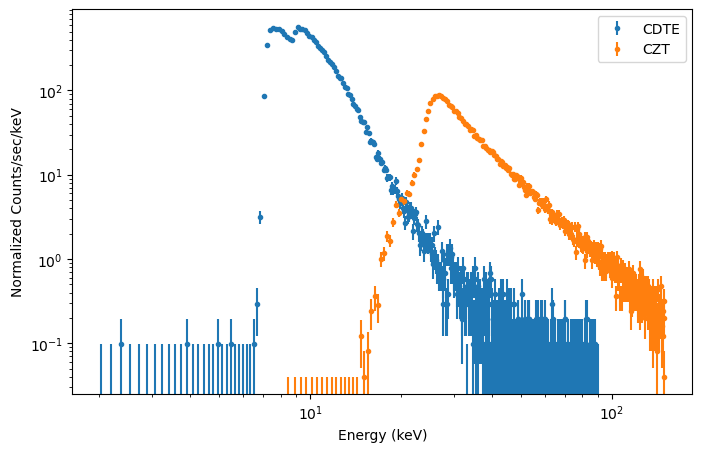

In [31]:
# Extract the data arrays for CdTe (s1)
x = Plot.x(1)
y = Plot.y(1)
y_err = Plot.yErr(1)

# Extract data arrays for CZT (s2)
x2 = Plot.x(2)
y2 = Plot.y(2)
y2_err = Plot.yErr(2)

# 3. Plot using matplotlib
plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=y_err, fmt='.', label='CDTE')
plt.errorbar(x2, y2, yerr=y2_err, fmt='.', label='CZT')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel('Normalized Counts/sec/keV')
plt.legend()
plt.show()

### Note the figure very carefully - the USEABLE CdTe energies before the error bars start to dominate ~35 keV. Similarly for the CZT, the usable lower-energies, making sure to avoid the "hump" at 25 keV, and its tail, is ~30 keV. We must curate the CdTe "fitend" and CZT "fitstart" so that we have at least 3 to 5 keV overlap between the two detectors. 
### Note: The energy resolution at 60 keV for CdTe is 1.5 keV, while for CZT is ~8 keV!!! Keep this in mind while interpreting the scaling constant. 

In [32]:
# setting the energy ranges for fitting. 
# CdTe
fitstart1 = 10.0 # 10 keV
fitend1   = 35.0 # 30 keV
# CZT
fitstart2 = 30.0 # 30 keV
fitend2 = 120.0 # 120 keV

In [33]:
s1.ignore(f"**-{fitstart1} {fitend1}-**")
s2.ignore(f"**-{fitstart2} {fitend2}-**")

    47 channels (1-47) ignored in spectrum #     1
   320 channels (192-511) ignored in spectrum #     1

    53 channels (1-53) ignored in spectrum #     2
    72 channels (270-341) ignored in spectrum #     2



In [36]:
# you need to run this before replotting using matplotlib
Plot('ldata')

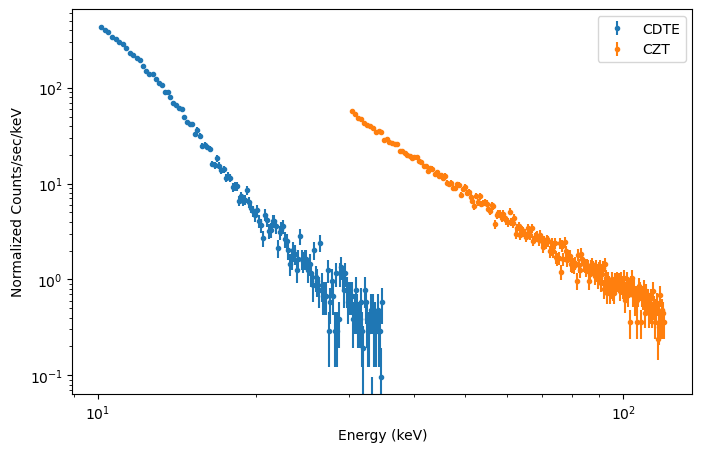

In [37]:
# Let us plot again
x = Plot.x(1)
y = Plot.y(1)
y_err = Plot.yErr(1)

# Extract data arrays for CZT (s2)
x2 = Plot.x(2)
y2 = Plot.y(2)
y2_err = Plot.yErr(2)

# 3. Plot using matplotlib
plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=y_err, fmt='.', label='CDTE')
plt.errorbar(x2, y2, yerr=y2_err, fmt='.', label='CZT')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel('Normalized Counts/sec/keV')
plt.legend()
plt.show()

In [75]:
# Let us now create a model 
m1 = Model("const*(apec+pow)")
# we have two "data groups" - assuming both detectors are observing a common source which emits thermal and non-thermal radiation
# we are assigning m2 to the second data group, i.e. CZT
m2 = AllModels(2) 


Model constant<1>(apec<2> + powerlaw<3>) Source No.: 1   Active/On
Model fractional systematic error = 0.03
Model Model Component  Parameter  Unit     Value
 par  comp
                           Data group: 1
   1    1   constant   factor              1.00000      +/-  0.0          
   2    2   apec       kT         keV      1.00000      +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                1.00000      +/-  0.0          
   6    3   powerlaw   PhoIndex            1.00000      +/-  0.0          
   7    3   powerlaw   norm                1.00000      +/-  0.0          
                           Data group: 2
   8    1   constant   factor              1.00000      = p1
   9    2   apec       kT         keV      1.00000      = p2
  10    2   apec       Abundanc            1.00000      = p3
  11    2   apec       Redshift            0.0          = p4
  12

## Excerpt from our One Year of HEL1OS Paper on the qualitative definition of constant:
"Qualitatively, the cross-detector normalization constant is an empirical correction factor that absorbs systematic discrepancies between two independent detector systems during joint forward-folded spectral modeling. Rather than being a static instrument-to-instrument ratio, its value is driven by the mathematical interplay between the chosen physical model, the instrument response matrices, and the real-time photon flux. During our combined detector solar flare fitting survey, we find that this constant is uniquely dynamic due to the combination of typically narrow energy overlap windows between the two detectors (3 to 5 keV) and highly steep, fast evolving spectra."

In [76]:
# Let us take the "constant" from the Data group 1, and freeze it. This implies, the CdTe is the reference detector now.
p1 = getattr(m1.constant,'factor')
p1.frozen= True
# Let us set the kT value in apec to 2.0
p2 = getattr(m1.apec,'kT')
p2.values = 2.0
# Let us set the power law index to 3.5
p6 = getattr(m1.powerlaw,'PhoIndex')
p6 = 3.5


Fit statistic  : Chi-Squared                59034.39     using 144 bins, spectrum 1, group 1.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1
                 Chi-Squared                31878.36     using 216 bins, spectrum 2, group 2.
Total fit statistic                         90912.74     with 356 d.o.f.

Test statistic : Chi-Squared                90912.74     using 360 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 356 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                59034.38     using 144 bins, spectrum 1, group 1.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1
                 Chi-Squared                31878.36     using 216 bins, spectrum 2, group 2.
Total fit statistic                         90

### If you notice, the Data group 2, i.e. CZT parameters are "tied" to the CdTe model parameters. 
### This makes sense because of our assumption that the near-simultaneous thermal and non-thermal radiation from the flaring plasma is being observed by both detectors. 
### However--- the "constant" of m2, or the model corresponding to CZT should be untied, and not frozen. Out of all the m2 parameters, this is the only one that is allowed to vary. Reason is that the thermal (apec) and non-thermal (powerlaw) models have 5 keV overlap between CdTe and CZT to "play around". For a given set of models, the fitting algorithm has to figure out the optimum scaling factor that will result in the counts observed. 

In [77]:
# let us now handle the constant for m2
p8 = getattr(m2.constant,'factor')
p8.untie()


Fit statistic  : Chi-Squared                59034.38     using 144 bins, spectrum 1, group 1.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1
                 Chi-Squared                31878.36     using 216 bins, spectrum 2, group 2.
Total fit statistic                         90912.74     with 356 d.o.f.

Test statistic : Chi-Squared                90912.74     using 360 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 356 degrees of freedom
 Current data and model not fit yet.


In [78]:
AllModels.show()


Parameters defined:
Model constant<1>(apec<2> + powerlaw<3>) Source No.: 1   Active/On
Model fractional systematic error = 0.03
Model Model Component  Parameter  Unit     Value
 par  comp
                           Data group: 1
   1    1   constant   factor              1.00000      frozen
   2    2   apec       kT         keV      2.00000      +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                1.00000      +/-  0.0          
   6    3   powerlaw   PhoIndex            1.00000      +/-  0.0          
   7    3   powerlaw   norm                1.00000      +/-  0.0          
                           Data group: 2
   8    1   constant   factor              1.00000      frozen
   9    2   apec       kT         keV      2.00000      = p2
  10    2   apec       Abundanc            1.00000      = p3
  11    2   apec       Redshift            0.0         

In [79]:
# Now you see that the constant of m2 is frozen; we don't want that! 
p8.frozen=False
AllModels.show()


Fit statistic  : Chi-Squared                59034.38     using 144 bins, spectrum 1, group 1.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1
                 Chi-Squared                31878.36     using 216 bins, spectrum 2, group 2.
Total fit statistic                         90912.74     with 355 d.o.f.

Test statistic : Chi-Squared                90912.74     using 360 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 355 degrees of freedom
 Current data and model not fit yet.

Parameters defined:
Model constant<1>(apec<2> + powerlaw<3>) Source No.: 1   Active/On
Model fractional systematic error = 0.03
Model Model Component  Parameter  Unit     Value
 par  comp
                           Data group: 1
   1    1   constant   factor              1.00000      frozen
   2    2   apec       kT         keV      2.000

In [80]:
# set systematic errors
AllModels.systematic=0.03


 The default systematic error for models is set to 0.03


Fit statistic  : Chi-Squared                59034.38     using 144 bins, spectrum 1, group 1.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1
                 Chi-Squared                31878.36     using 216 bins, spectrum 2, group 2.
Total fit statistic                         90912.74     with 355 d.o.f.

Test statistic : Chi-Squared                90912.74     using 360 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 355 degrees of freedom
 Current data and model not fit yet.


In [81]:
Fit.perform()

                                   Parameters
Chi-Squared  |beta|/N    Lvl          2:kT        5:norm    6:PhoIndex        7:norm      8:factor
68624.3      179.774       3       34.8658       1526.65       1.00000       8.60732       1.00001
68526.5      9981.4        2       34.8450       1525.91       1.00028       8.59664      0.999480
67617.5      9918.84       1       34.6458       1518.87       1.00293       8.49378      0.994445
62764.3      9325.47       0       33.2742       1479.27       1.02259       7.74780      0.960443
58339.7      5644.36       0       31.0677       1570.07       1.08203       5.79048      0.913576
56613.9      912.82       -1       25.3069       2213.48       1.11863       4.86096      0.858657
55346.7      568.349      -1       21.7867       3122.10       1.10757       4.98218      0.804907
54223        590.538      -1       19.4525       4282.15       1.07629       5.48329      0.736968
53252.5      440.738      -1       17.2737       5804.00       

In [82]:
# reduced chi-square 
458.31/355

1.2910140845070424

In [83]:
# 90% confidence errors on constant, kT and power-law index
Fit.error("2.706 8 2 6")

 Parameter   Confidence Range (2.706)
     8      1.58585      1.80665    (-0.103687,0.117115)
     2      1.73977      1.78232    (-0.0197318,0.0228193)
     6      3.50095      3.56841    (-0.033413,0.0340422)


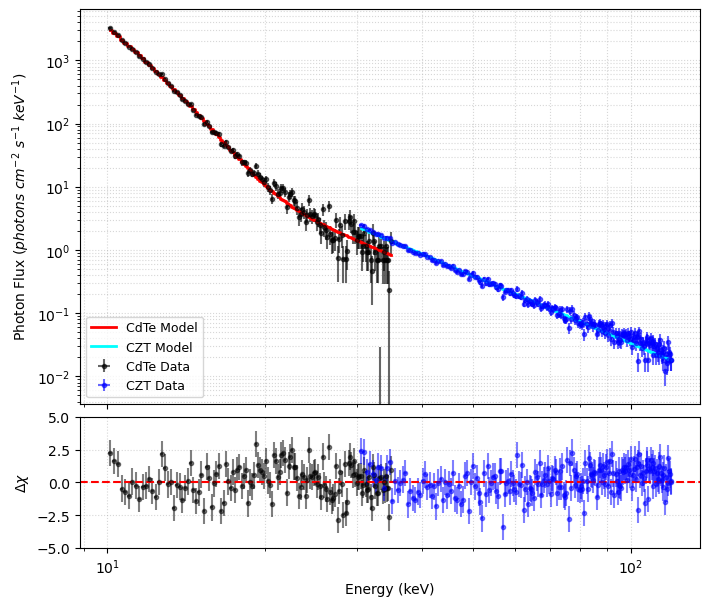

In [84]:
# Plotting
# 1. Reset the Plot
Plot('ldata')

# 2. We are going to plot the unfolded photon flux! We are now going to the physical units, instead of engineering units of counts/sec/keV.
Plot("uf delchi")

# --- SPECTRUM 1: CdTe (Plot Group 1) ---
energies_1 = Plot.x(1)         # Energy grid for CdTe
energy_errs_1 = Plot.xErr(1)   
# Window 1 = Unfolded Flux
euf_data_1 = Plot.y(1, 1)      
euf_errs_1 = Plot.yErr(1, 1)    
euf_model_1 = Plot.model(1)     
# Window 2 = Residuals
residuals_1 = Plot.y(1, 2)     
res_errs_1 = Plot.yErr(1, 2)   

# --- SPECTRUM 2: CZT (Plot Group 2) ---
energies_2 = Plot.x(2)         # Energy grid for CZT (Prevents ValueError)
energy_errs_2 = Plot.xErr(2)   
# Window 1 = Unfolded Flux
euf_data_2 = Plot.y(2, 1)      
euf_errs_2 = Plot.yErr(2, 1)    
euf_model_2 = Plot.model(2)     
# Window 2 = Residuals
residuals_2 = Plot.y(2, 2)     
res_errs_2 = Plot.yErr(2, 2)   

# 3. Create the 2-panel layout with shared X-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True, 
                               gridspec_kw={'height_ratios':[3,1], 'hspace': 0.05})

# === TOP PANEL: Unfolded Flux Display ===
# Plot CdTe Data and Model (Black/Red)
ax1.errorbar(energies_1, euf_data_1, xerr=energy_errs_1, yerr=euf_errs_1, 
             fmt='.', color='black', alpha=0.6, label='CdTe Data')
ax1.step(energies_1, euf_model_1, where='mid', color='red', linewidth=2, label='CdTe Model')

# Plot CZT Data and Model (Blue/Cyan)
ax1.errorbar(energies_2, euf_data_2, xerr=energy_errs_2, yerr=euf_errs_2, 
             fmt='.', color='blue', alpha=0.6, label='CZT Data')
ax1.step(energies_2, euf_model_2, where='mid', color='cyan', linewidth=2, label='CZT Model')

ax1.set_yscale('log')
ax1.set_ylabel(r'Photon Flux ($photons\ cm^{-2}\ s^{-1}\ keV^{-1}$)')
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(True, which='both', linestyle=':', alpha=0.5)

# === BOTTOM PANEL: Joint Delchi Residuals ===
# Plot CdTe Residuals
ax2.errorbar(energies_1, residuals_1, xerr=energy_errs_1, yerr=res_errs_1, fmt='.', color='black', alpha=0.5)

# Plot CZT Residuals
ax2.errorbar(energies_2, residuals_2, xerr=energy_errs_2, yerr=res_errs_2, fmt='.', color='blue', alpha=0.5)

ax2.axhline(0, color='red', linestyle='--') # Baseline zero marker
ax2.set_ylabel(r'$\Delta\chi$')
ax2.set_xlabel('Energy (keV)')
ax2.set_xscale('log') 
ax2.grid(True, which='both', linestyle=':', alpha=0.5)

# Adjust plot view boundaries tightly to isolate outliers
ax2.set_ylim(-5, 5) 

plt.show()


In [74]:
AllModels.clear()